In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# check out the data

In [2]:
!ls data/

current_foreground_noise_model.dat  full_noise_model.dat
current_instrument_noise_model.dat  instrument_noise_model.dat
current_sgwb_noise_model.dat        power_data.dat
dft_data.dat                        scaleogram_data.dat
dwt_data.dat                        sgwb_noise_model.dat
foreground_noise_model.dat


In [67]:
scaleogram_data = np.loadtxt('data/scaleogram_data.dat')
full_noise = np.loadtxt('data/full_noise_model.dat')
dwt_data = np.loadtxt('data/dwt_data.dat')

FileNotFoundError: data/scaleogram_data.dat not found.

In [139]:
full_noise = np.loadtxt('dbg_wavelet_scaleogram.dat')
dwt_data = np.loadtxt('./dwt_data.dat')
scaleogram_data = np.loadtxt('./scaleogram_data.dat')

In [140]:
# cols are t, f, |X|^2, |Y|^2, |Z|^2

In [141]:
full_noise.shape

(51714, 8)

In [142]:
dwt_data.shape

(51714, 5)

In [143]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from matplotlib import colors
%matplotlib inline

def get_Nt_Nf(datafile_arr):
    # cols are t, f, ...
    Nf = np.unique(datafile_arr[:,1]).shape[0]
    Nt = np.unique(datafile_arr[:,0]).shape[0]
    assert Nt*Nf == datafile_arr.shape[0]
    return Nt,Nf

# TODO: separate real/imag FFT coeffs in each layer
def wavelet_specgram(t, f, pz, Nt = 512, clip = 0, lognorm=False, cmap='bwr', cx_norm='abs'):
    Nf = t.shape[0] // Nt
    if t.shape[0] != Nt*Nf or f.shape[0] != Nt*Nf:
        print("Nt or Nf is wrong")
    z = pz.copy()
    if lognorm:
        z = np.ma.masked_less_equal(z.astype(float), 0)
        lo, hi = np.nanpercentile(z.compressed(), [clip, 100-clip])
        norm = colors.AsinhNorm(vmin=lo, vmax = hi, clip=True)
    else:
        lo, hi = np.nanpercentile(z, [clip, 100-clip])
        norm = colors.Normalize(vmin=lo, vmax = hi, clip=True)
    #plt.imshow(z.reshape((Nf,Nt)),cmap=cmap,norm=norm,aspect=9/16*Nt/Nf,interpolation='none')
    fig, ax = plt.subplots()
    m = ax.pcolormesh(t[::Nf], f[:Nf], z.reshape((Nt,Nf)).T, cmap=cmap, norm=norm, shading='auto',snap=True, rasterized=True)
    fig.colorbar(m,ax=ax)
    plt.xlabel('t')
    plt.ylabel('f')
    plt.show()
    

In [144]:
Nt,Nf = get_Nt_Nf(full_noise)

In [145]:
np.max(dwt_data[:,2])

5.61079970644053e-21

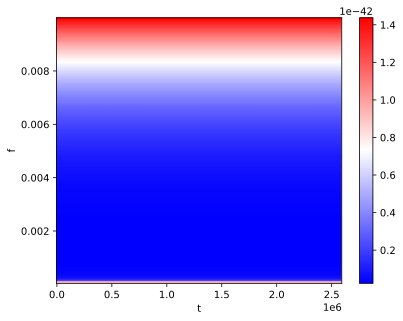

In [146]:
wavelet_specgram(full_noise[:,0], full_noise[:,1], full_noise[:,2], Nt=Nt)

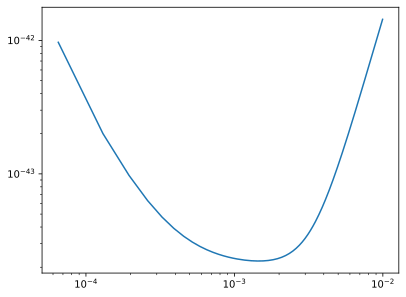

In [147]:
plt.loglog(full_noise[:Nf,1],full_noise[:Nf,2])

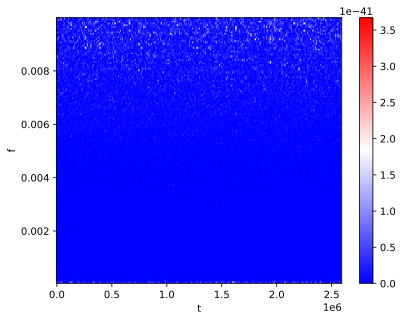

In [148]:
wavelet_specgram(scaleogram_data[:,0], scaleogram_data[:,1], scaleogram_data[:,2], Nt=Nt)

In [151]:
np.max(counts)

0.4133455713272516

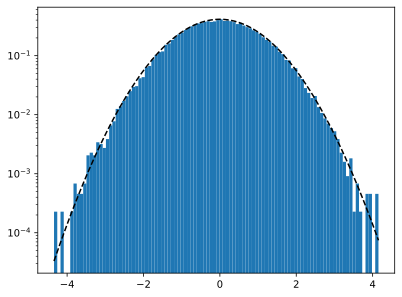

In [154]:
# gaussianity test of generated data
# fudge_factor = 3 # implemented in code
counts,bins,_ = plt.hist(dwt_data[:,4] / np.sqrt(2*full_noise[:,4]), density=True, bins=100)
x = np.linspace(bins[0],bins[-1],100)
plt.plot(x, np.exp(-x**2 / 2)*np.max(counts), color='k', linestyle = '--')
plt.yscale('log')

In [152]:
  whitened = dwt_data[:,4] / np.sqrt(full_noise[:,4])
  print(f"Whitened variance: {np.var(whitened):.4f}")

Whitened variance: 1.9831


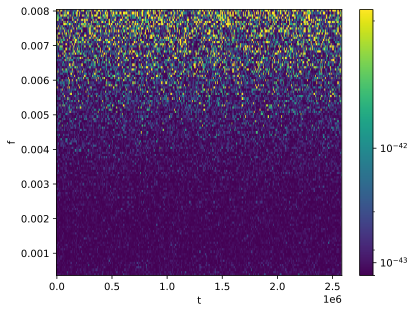

In [711]:
wavelet_specgram(scaleogram_data[:,0], scaleogram_data[:,1], scaleogram_data[:,2], Nt=337, clip=3, lognorm=True, cmap='viridis')

In [712]:
current_inst = np.loadtxt('data/current_instrument_noise_model.dat')
# note that this is frequency-layers only

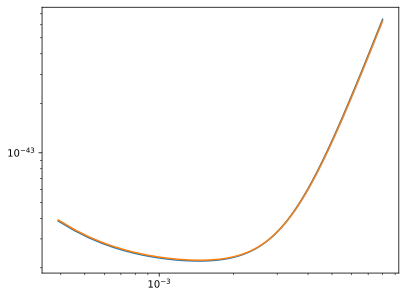

ratio: [1.01500505 1.01457008 1.01420699 1.01390438 1.01364909 1.01342568
 1.01323009 1.01304963 1.01288091 1.01271271 1.01255225 1.01237544
 1.01219458 1.01199755 1.01179319 1.01155757 1.0113115  1.01103432
 1.01073709 1.01040791 1.01004856 1.00966535 1.00924234 1.0087951
 1.00830839 1.00778946 1.00723709 1.00665474 1.00604605 1.00540272
 1.0047334  1.00403882 1.00332393 1.00258254 1.00183135 1.00106112
 1.00028119 0.99949365 0.99870395 0.99790787 0.99711415 0.99632484
 0.99554201 0.9947676  0.99400351 0.99325654 0.99252284 0.99180622
 0.99110548 0.99042391 0.98976637 0.98912695 0.98850827 0.98791425
 0.98733937 0.98678562 0.98625613 0.98574577 0.98525891 0.9847907
 0.98434369 0.98391471 0.98350718 0.9831168  0.98274431 0.98238923
 0.98205204 0.98173005 0.98142665 0.98112915 0.98085201 0.9805865
 0.98033323 0.98009247 0.97985732 0.97964975 0.97944125 0.97923999
 0.97905257 0.9788729  0.97870154 0.97853879 0.97838473 0.97823455
 0.97809377 0.97796236 0.97783594 0.97771043 0.97759499 0.

In [714]:
plt.loglog(current_inst[:,0],current_inst[:,1], label="current noise")
Nf = full_noise.shape[0] // 337
plt.loglog(full_noise[:Nf,1], full_noise[:Nf,2], label="injection")
plt.show()
print(f"ratio: {full_noise[:Nf,2] / current_inst[:,1]}")

# check out the chains

In [2]:
sgwb = np.loadtxt('chains-bug/sgwb_chain.dat')#, max_rows=900)

In [130]:
sgwb = np.loadtxt('chains-sgwb-only/sgwb_chain.dat')

In [66]:
N = 1000
sgwb = np.loadtxt('chains/sgwb_chain.dat', max_rows=N)
inst = np.loadtxt('chains/noise_chain.dat', max_rows=N)
galx = np.loadtxt('chains/foreground_chain.dat', max_rows=N)

FileNotFoundError: chains/sgwb_chain.dat not found.

In [51]:
# check if there's a bias from current point to injection

In [52]:
sgwb.shape

(3000, 4)

In [53]:
inst.shape

(3000, 14)

In [54]:
galx.shape

(3000, 7)

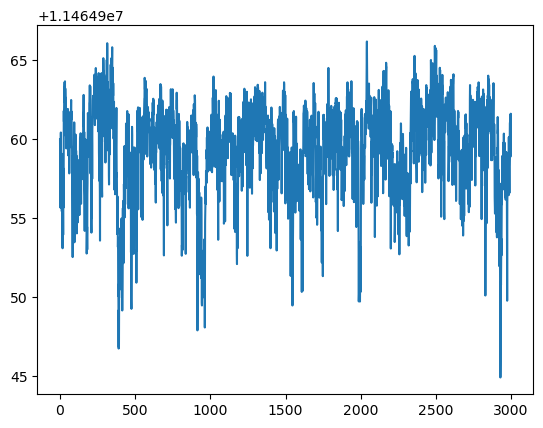

In [55]:
plt.plot(inst[:,1])

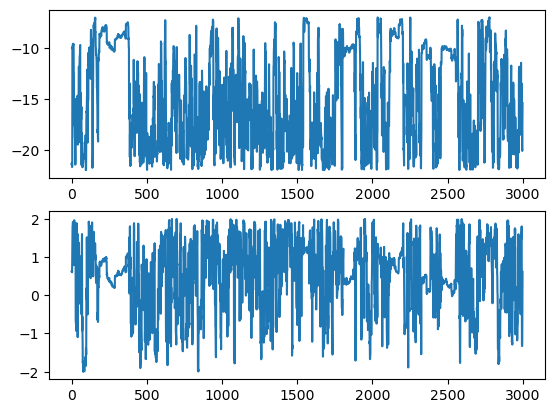

In [56]:
# sgwb trace

fig, ax = plt.subplots(2,1)
ax[0].plot(sgwb[0:,2])
ax[1].plot(sgwb[0:,3])

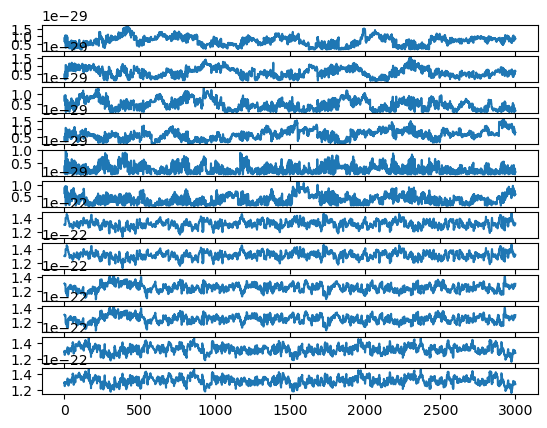

In [57]:
# inst trace
burn = 0
fig, ax = plt.subplots(12,1)
for i in range(12):
    ax[i].plot(inst[burn:,i+2])

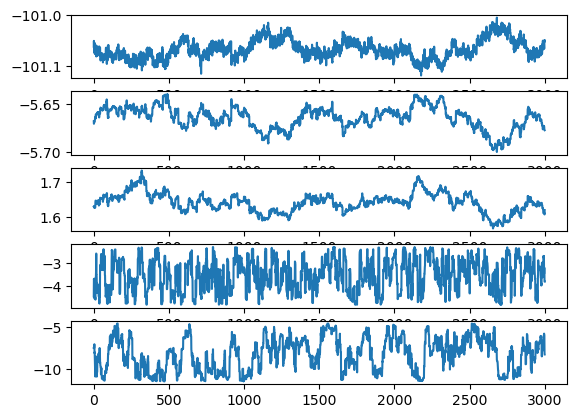

In [58]:
burn = 0
fig, ax = plt.subplots(5,1)
for i in range(5):
    ax[i].plot(galx[burn:,i+2])

In [59]:
from corner import corner

In [60]:
burn = 0
sgwb_chain = np.array(
    [
        sgwb[burn:,2], # logA
        sgwb[burn:,3], # alpha
    ]).T
sgwb_labels = [r'$\log A_p$', r'$\alpha$']

In [61]:
inst_chain = np.array(
    [
        inst[burn:,i+2]
        for i in range(12)
    ]).T
inst_labels = [r'$\log S_{\mathrm{acc},12}$',
r'$\log S_{\mathrm{acc},21}$',
r'$\log S_{\mathrm{acc},13}$',
r'$\log S_{\mathrm{acc},31}$',
r'$\log S_{\mathrm{acc},23}$', 
r'$\log S_{\mathrm{acc},32}$', 
r'$\log S_{\mathrm{oms},12}$', 
r'$\log S_{\mathrm{oms},21}$', 
r'$\log S_{\mathrm{oms},13}$', 
r'$\log S_{\mathrm{oms},31}$', 
r'$\log S_{\mathrm{oms},23}$', 
r'$\log S_{\mathrm{oms},32}$']

In [62]:
galx_chain = np.array(
    [
        galx[burn:,i+2]
        for i in range(5)
    ]).T
galx_labels = [r'$\log A$', r'$f_1$', r'$\alpha$', r'$f_k$', r'$f_2$']

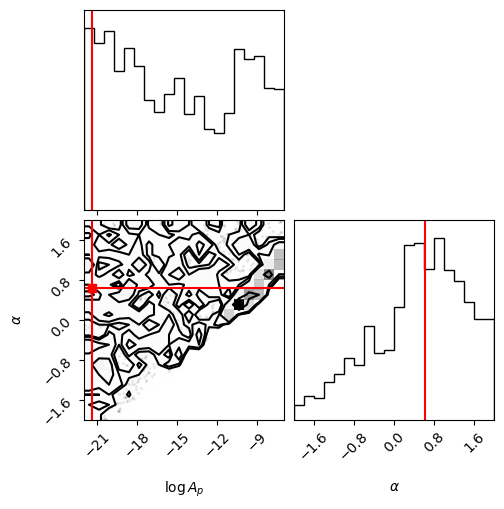

In [63]:
truths = sgwb[0,2:]
corner(sgwb_chain, labels = sgwb_labels, truths=truths, truth_color = 'red')
plt.show()

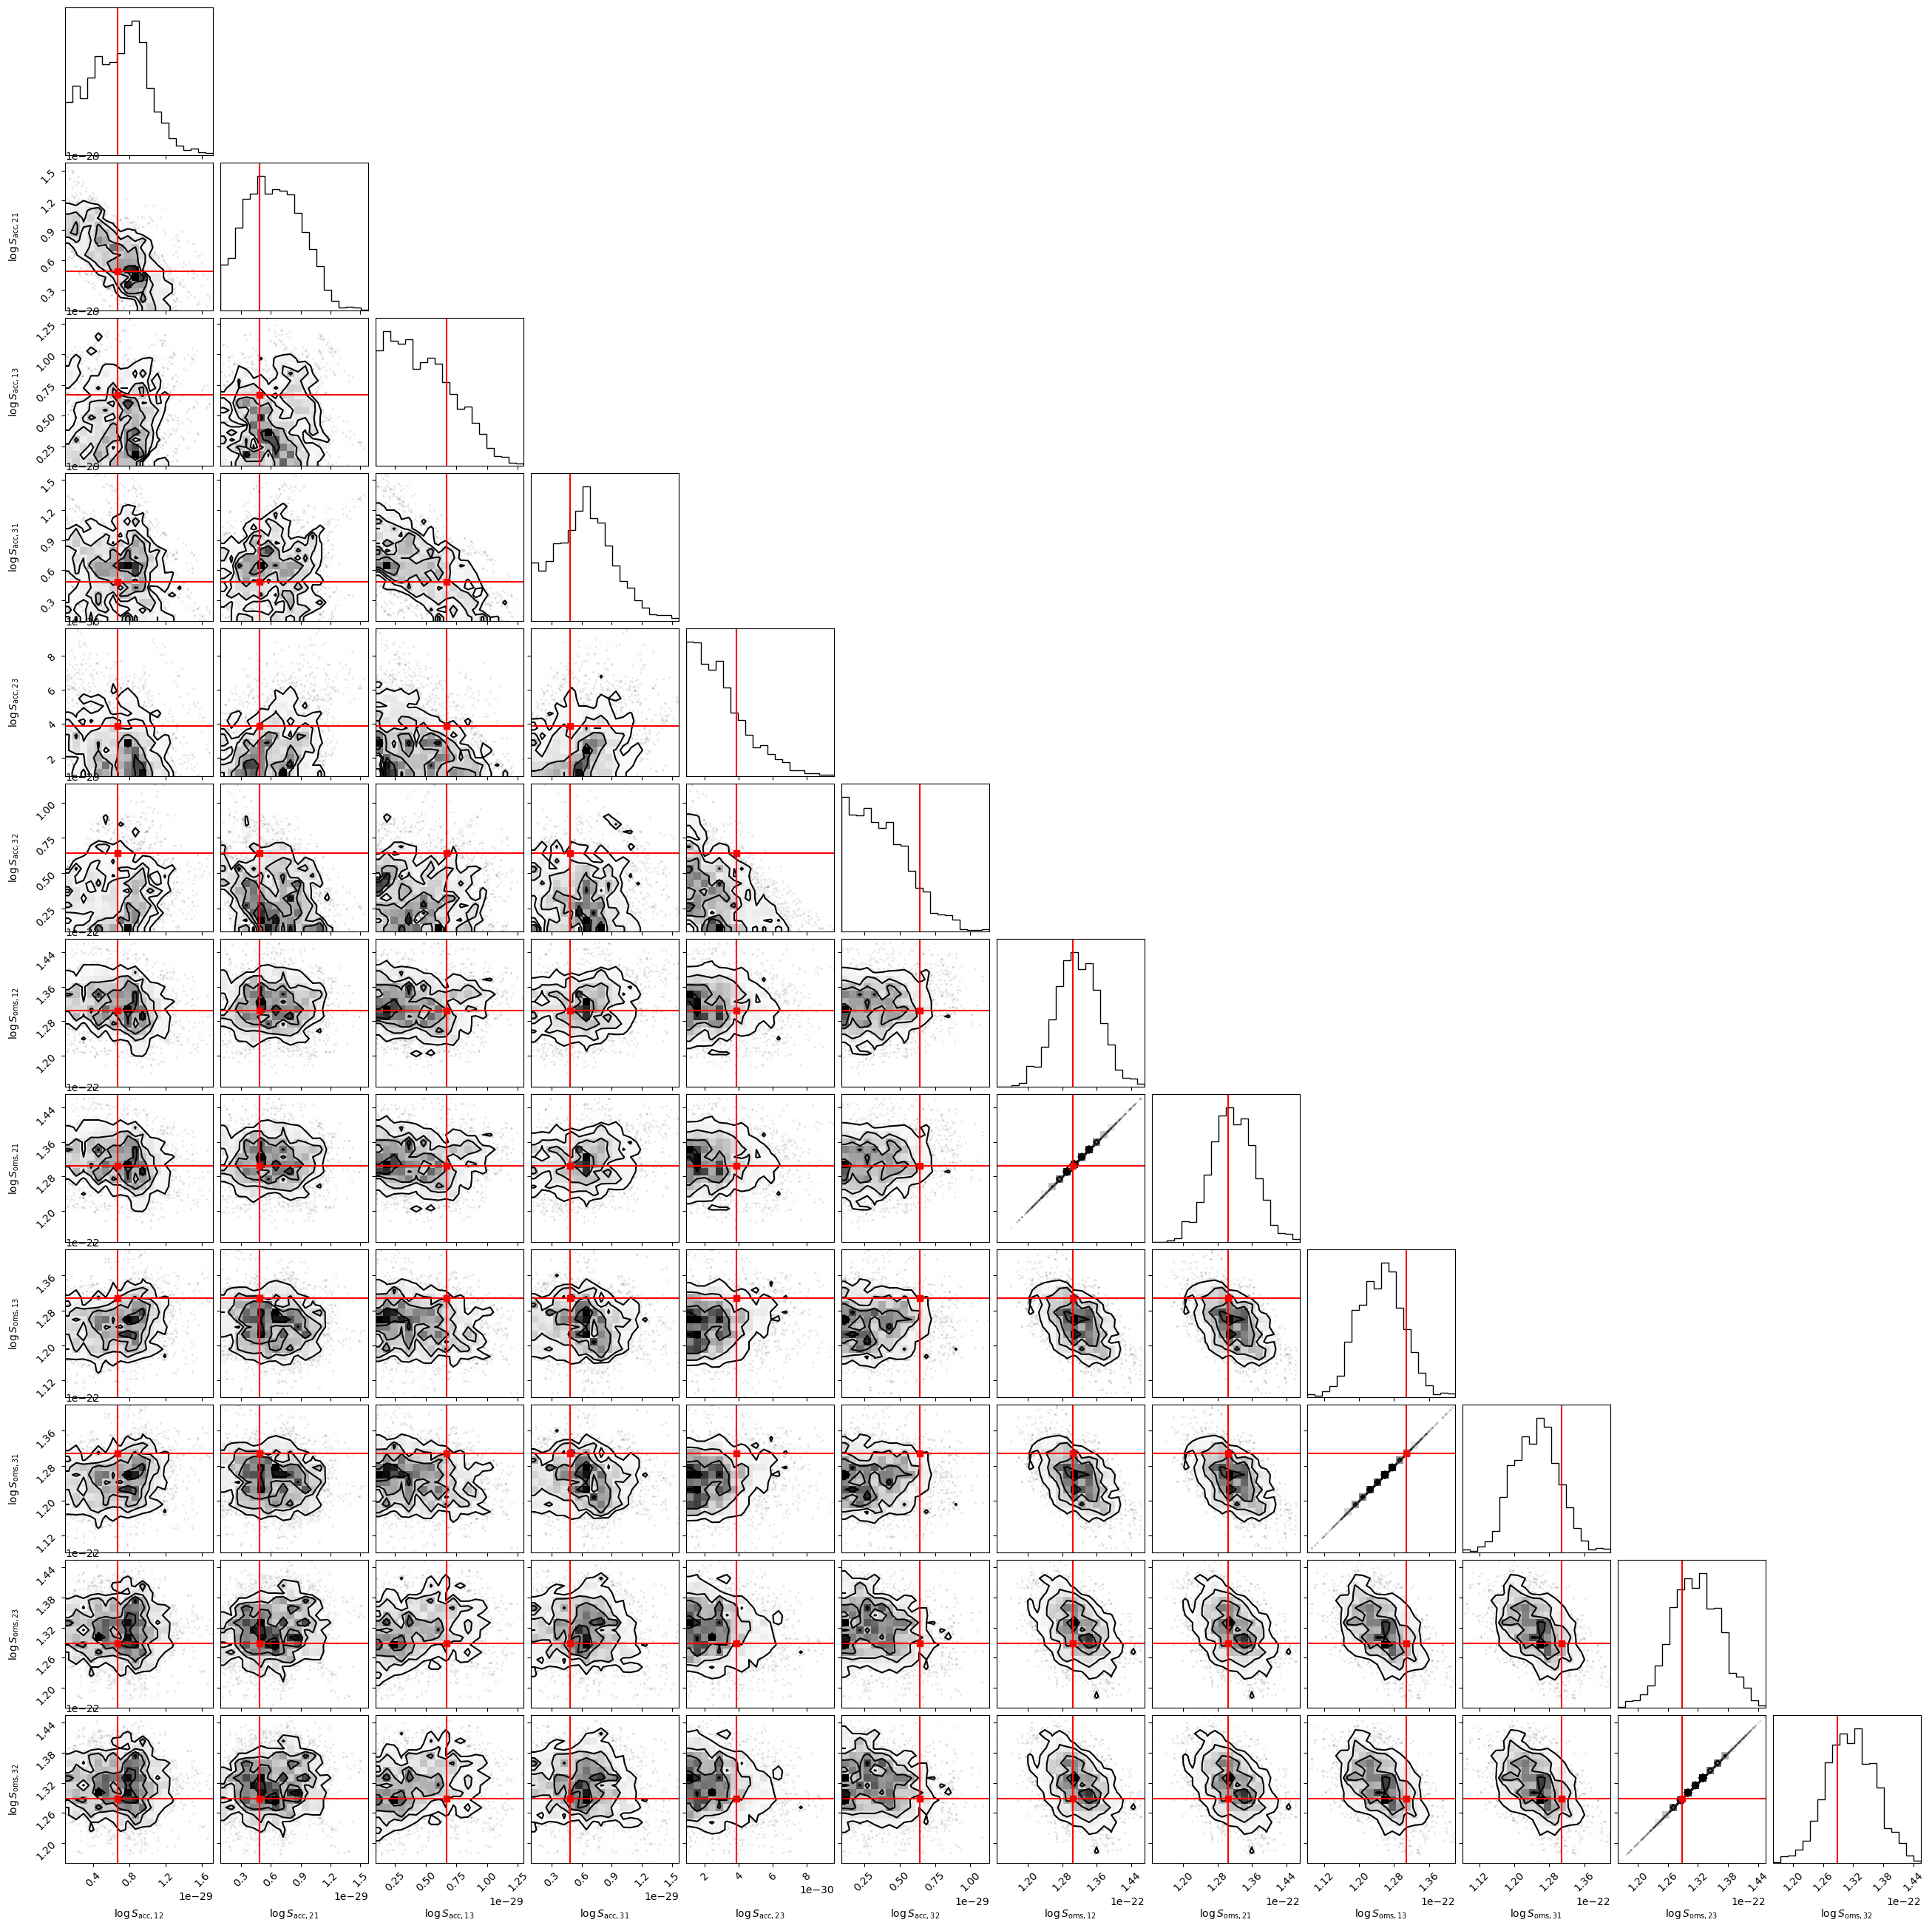

In [64]:
truths = inst[0,2:]
corner(inst_chain, labels = inst_labels, truths = truths, truth_color='red')
plt.show()

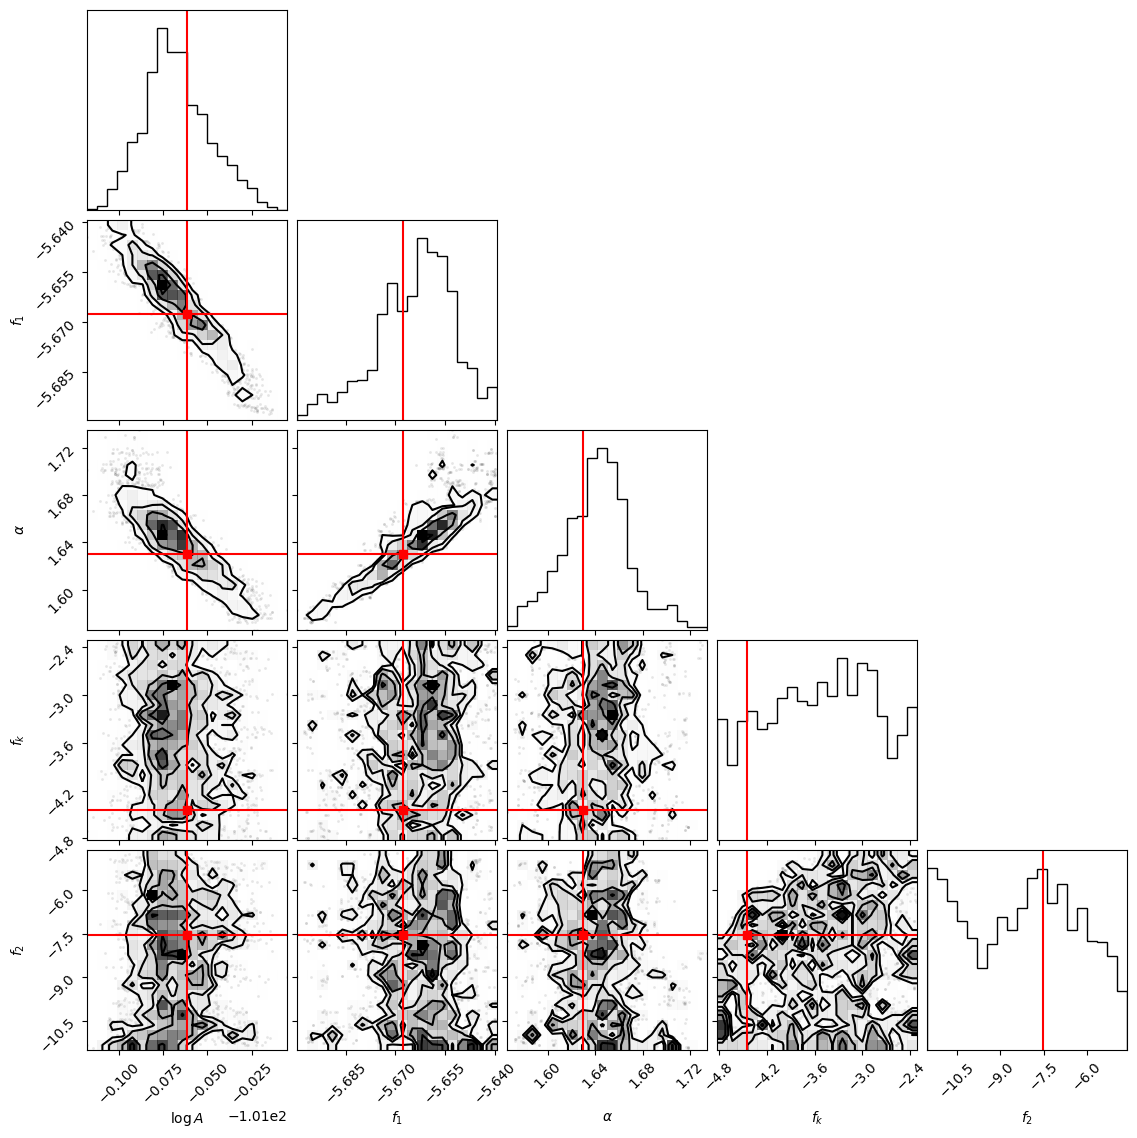

In [65]:
truths = galx[0,2:]
corner(galx_chain, labels = galx_labels, truths = truths, truth_color = 'red')
plt.show()